In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.multitest import fdrcorrection_twostage

import warnings
warnings.filterwarnings("ignore")

In [87]:
cd C:\Users\tr432\Downloads\filter_GutLungAxis_Week0\lefse

C:\Users\tr432\Downloads\filter_GutLungAxis_Week0\lefse


In [88]:
## 리눅스 lefse 환경의 run_lefse.py 단계에서 -a 1.0 / -w 1.0 / -l 0 으로 설정한 후 나온 파일 (모든 features의 p-value가 나와있는 파일)을 넣어야함
# -> 그래야 fdr correction 가능
df = pd.read_csv('output_raw.res', sep='\t', header=None)

df.rename(columns={df.columns[0]: "Features"}, inplace=True)
df.rename(columns={df.columns[1]: "LD1"}, inplace=True)
df.rename(columns={df.columns[2]: "Group"}, inplace=True)
df.rename(columns={df.columns[3]: "LD2"}, inplace=True)
df.rename(columns={df.columns[4]: "p-val"}, inplace=True)

df.head(5)

,Features,LD1,Group,LD2,p-val
0,d__Bacteria.p__Bacillota_I.c__Bacilli_A.o__Sta...,3.739248,VNAM,3.282890,0.194850648609
1,d__Archaea,1.488307,Control,0.945361,0.847944894792
2,d__Bacteria.p__Bacillota_A_368345.c__Clostridi...,3.988562,VNAM,3.376860,0.0451269488887
3,d__Bacteria.p__Bacillota_A_368345.c__Clostridi...,1.468990,Control,2.260869,0.414216178243
4,d__Bacteria.p__Bacillota_I.c__Bacilli_A.o__Bac...,2.605897,Control,2.297500,0.949038904488


In [89]:
new_cols = df['Features'].str.split('.', expand=True)
new_cols.columns = ['Kingdom', 'Phylum', 'Class', 'Order', 'Family', 'Genus']

df = pd.concat([new_cols, df], axis=1)
df = df.drop(columns=['Features'])

## 원하는 taxa level + 그룹명만 가져옴
cols = ['Phylum', 'Family', 'Genus'] + df.columns[6:].tolist()
df = df[cols]

df = df.replace('__', '_', regex=True)

df

,Phylum,Family,Genus,LD1,Group,LD2,p-val
0,p_Bacillota_I,None,None,3.739248,VNAM,3.282890,0.194850648609
1,None,None,None,1.488307,Control,0.945361,0.847944894792
2,p_Bacillota_A_368345,f_Clostridiaceae_222000,g_Dwaynesavagella,3.988562,VNAM,3.376860,0.0451269488887
3,p_Bacillota_A_368345,f_Aristaeellaceae,f_Aristaeellaceae_x_L6,1.468990,Control,2.260869,0.414216178243
4,p_Bacillota_I,f_Amphibacillaceae,None,2.605897,Control,2.297500,0.949038904488
...,...,...,...,...,...,...,...
418,p_Bacillota_A_368345,f_Lachnospiraceae,g_Schaedlerella,3.562496,VNAM,2.868824,0.194451829212
419,p_Bacillota_I,f_Carnobacteriaceae,g_Atopostipes,2.579258,Control,2.280889,0.506197594793
420,p_Bacillota_A_368345,f_Lachnospiraceae,g_Anaerobutyricum,1.692525,VNAM,1.488895,0.690328329464
421,p_Bacillota_A_368345,f_Anaerofustaceae,g_Anaerofustis,0.526481,Control,2.189111,0.414216178243


In [90]:
df[df['Family'] == 'f_Muribaculaceae']

,Phylum,Family,Genus,LD1,Group,LD2,p-val
56,p_Bacteroidota,f_Muribaculaceae,g_Amulumruptor,4.549479,Control,3.787223,0.345778586151
113,p_Bacteroidota,f_Muribaculaceae,None,4.550155,Control,3.780237,0.345778586151
131,p_Bacteroidota,f_Muribaculaceae,f_Muribaculaceae_x_L6,2.198676,VNAM,1.906314,0.749295270453
248,p_Bacteroidota,f_Muribaculaceae,g_Lepagella,1.912837,VNAM,2.128323,0.22067136192
298,p_Bacteroidota,f_Muribaculaceae,g_Paramuribaculum,0.923706,VNAM,2.191245,0.22067136192


In [91]:
mask = ((df['Family'] == 'f_Muribaculaceae') &
        (df['Genus'].isna() | (df['Genus'] == 'None')))

df.loc[mask, 'Genus'] = 'f_Muribaculaceae; g_unclassified'

In [92]:
df[df['Family'] == 'f_Muribaculaceae']

,Phylum,Family,Genus,LD1,Group,LD2,p-val
56,p_Bacteroidota,f_Muribaculaceae,g_Amulumruptor,4.549479,Control,3.787223,0.345778586151
113,p_Bacteroidota,f_Muribaculaceae,f_Muribaculaceae; g_unclassified,4.550155,Control,3.780237,0.345778586151
131,p_Bacteroidota,f_Muribaculaceae,f_Muribaculaceae_x_L6,2.198676,VNAM,1.906314,0.749295270453
248,p_Bacteroidota,f_Muribaculaceae,g_Lepagella,1.912837,VNAM,2.128323,0.22067136192
298,p_Bacteroidota,f_Muribaculaceae,g_Paramuribaculum,0.923706,VNAM,2.191245,0.22067136192


In [93]:
df2 = df.dropna(subset=['Group'])
df2 = df2.dropna(subset=['Genus'])
df2 = df2[df2['Genus'].astype(str).str.startswith(('g_', 'f_Muribaculaceae'))].copy()
df2

,Phylum,Family,Genus,LD1,Group,LD2,p-val
2,p_Bacillota_A_368345,f_Clostridiaceae_222000,g_Dwaynesavagella,3.988562,VNAM,3.376860,0.0451269488887
7,p_Actinomycetota,f_Mycobacteriaceae,g_Corynebacterium,3.018304,VNAM,2.614989,0.0449352133253
8,p_Bacillota_I,f_UBA660,g_Scybalousia,3.027388,VNAM,2.509929,0.636143847451
10,p_Bacillota_I,f_UBA660,g_CAG_605,2.644770,Control,2.039044,0.904472282191
15,p_Bacteroidota,f_Bacteroidaceae,g_Alloprevotella,1.329008,VNAM,1.276497,0.238250391795
...,...,...,...,...,...,...,...
418,p_Bacillota_A_368345,f_Lachnospiraceae,g_Schaedlerella,3.562496,VNAM,2.868824,0.194451829212
419,p_Bacillota_I,f_Carnobacteriaceae,g_Atopostipes,2.579258,Control,2.280889,0.506197594793
420,p_Bacillota_A_368345,f_Lachnospiraceae,g_Anaerobutyricum,1.692525,VNAM,1.488895,0.690328329464
421,p_Bacillota_A_368345,f_Anaerofustaceae,g_Anaerofustis,0.526481,Control,2.189111,0.414216178243


In [94]:
df2[df2['Family'] == 'f_Muribaculaceae']

,Phylum,Family,Genus,LD1,Group,LD2,p-val
56,p_Bacteroidota,f_Muribaculaceae,g_Amulumruptor,4.549479,Control,3.787223,0.345778586151
113,p_Bacteroidota,f_Muribaculaceae,f_Muribaculaceae; g_unclassified,4.550155,Control,3.780237,0.345778586151
131,p_Bacteroidota,f_Muribaculaceae,f_Muribaculaceae_x_L6,2.198676,VNAM,1.906314,0.749295270453
248,p_Bacteroidota,f_Muribaculaceae,g_Lepagella,1.912837,VNAM,2.128323,0.22067136192
298,p_Bacteroidota,f_Muribaculaceae,g_Paramuribaculum,0.923706,VNAM,2.191245,0.22067136192


In [95]:
# 1) "-" 값을 NaN으로 변경
df2["p-val"] = df2["p-val"].replace("-", np.nan)

# 2) numeric 변환
df2["p-val"] = pd.to_numeric(df2["p-val"], errors="coerce")

# 3) NaN 행 제거
df2 = df2.dropna(subset=["p-val"])

In [96]:
## (선택1) FDR (BKY)

rej, qvals, _, _ = fdrcorrection_twostage(df2["p-val"].values, alpha=0.05, method="bky")  ## BKY(2006) two-stage linear step-up
df2["q-val"] = qvals

print(df2[["p-val", "q-val"]])
print(df2[df2["p-val"] < 0.05].shape[0])
print(df2[df2["q-val"] < 0.05].shape[0])

        p-val     q-val
2    0.045127  0.571416
7    0.044935  0.571416
8    0.636144  0.882153
10   0.904472  0.990531
15   0.238250  0.571416
..        ...       ...
418  0.194452  0.571416
419  0.506198  0.781855
420  0.690328  0.908293
421  0.414216  0.689767
422  0.220671  0.571416

[203 rows x 2 columns]
12
0


In [97]:
'''
## (선택2) FDR (Benjamini-Hochberg)

df2["p-val"] = pd.to_numeric(df2["p-val"], errors="coerce")

# BH-FDR (q-value) 계산
rej, qvals, _, _ = multipletests(df2["p-val"].values, alpha=0.05, method="fdr_bh")
df2["q-val"] = qvals

print(df2[["p-val", "q-val"]])
print(df2[df2["p-val"] < 0.05].shape[0])
print(df2[df2["q-val"] < 0.05].shape[0])
'''

'\n## (선택2) FDR (Benjamini-Hochberg)\n\ndf2["p-val"] = pd.to_numeric(df2["p-val"], errors="coerce")\n\n# BH-FDR (q-value) 계산\nrej, qvals, _, _ = multipletests(df2["p-val"].values, alpha=0.05, method="fdr_bh")\ndf2["q-val"] = qvals\n\nprint(df2[["p-val", "q-val"]])\nprint(df2[df2["p-val"] < 0.05].shape[0])\nprint(df2[df2["q-val"] < 0.05].shape[0])\n'

In [98]:
df_raw = df2.copy()
df_raw['Phylum'] = df_raw['Phylum'].str.replace(r'^p_', '', regex=True)
df_raw['Family'] = df_raw['Family'].str.replace(r'^f_', '', regex=True)
df_raw['Genus']  = df_raw['Genus'] .str.replace(r'^g_', '', regex=True)

#df_ld2.set_index('Genus', inplace=True)
df_raw.loc[df_raw['Group'] == 'Control', 'LD2'] *= -1  #Edit: LD2 값을 음수로 설정할 그룹명 입력

df_raw

,Phylum,Family,Genus,LD1,Group,LD2,p-val,q-val
2,Bacillota_A_368345,Clostridiaceae_222000,Dwaynesavagella,3.988562,VNAM,3.376860,0.045127,0.571416
7,Actinomycetota,Mycobacteriaceae,Corynebacterium,3.018304,VNAM,2.614989,0.044935,0.571416
8,Bacillota_I,UBA660,Scybalousia,3.027388,VNAM,2.509929,0.636144,0.882153
10,Bacillota_I,UBA660,CAG_605,2.644770,Control,-2.039044,0.904472,0.990531
15,Bacteroidota,Bacteroidaceae,Alloprevotella,1.329008,VNAM,1.276497,0.238250,0.571416
...,...,...,...,...,...,...,...,...
418,Bacillota_A_368345,Lachnospiraceae,Schaedlerella,3.562496,VNAM,2.868824,0.194452,0.571416
419,Bacillota_I,Carnobacteriaceae,Atopostipes,2.579258,Control,-2.280889,0.506198,0.781855
420,Bacillota_A_368345,Lachnospiraceae,Anaerobutyricum,1.692525,VNAM,1.488895,0.690328,0.908293
421,Bacillota_A_368345,Anaerofustaceae,Anaerofustis,0.526481,Control,-2.189111,0.414216,0.689767


In [99]:
df_raw.to_csv('lefse_ld3_BKY.csv', index=False)
df_raw[df_raw['Family'] == 'Muribaculaceae']

,Phylum,Family,Genus,LD1,Group,LD2,p-val,q-val
56,Bacteroidota,Muribaculaceae,Amulumruptor,4.549479,Control,-3.787223,0.345779,0.689767
113,Bacteroidota,Muribaculaceae,f_Muribaculaceae; g_unclassified,4.550155,Control,-3.780237,0.345779,0.689767
131,Bacteroidota,Muribaculaceae,f_Muribaculaceae_x_L6,2.198676,VNAM,1.906314,0.749295,0.939484
248,Bacteroidota,Muribaculaceae,Lepagella,1.912837,VNAM,2.128323,0.220671,0.571416
298,Bacteroidota,Muribaculaceae,Paramuribaculum,0.923706,VNAM,2.191245,0.220671,0.571416


In [100]:
df_ld3 = df_raw[(abs(df_raw['LD2']) >= 3) & (df_raw['q-val'] < 0.05)].copy()
#df_ld3.set_index('Genus', inplace=True)
print(df_ld3.head(3))
print(df_ld3.shape[0])

Empty DataFrame
Columns: [Phylum, Family, Genus, LD1, Group, LD2, p-val, q-val]
Index: []
0


In [101]:
df_ld3 = df_ld3.sort_values(by='LD2')
df_ld3

,Phylum,Family,Genus,LD1,Group,LD2,p-val,q-val


In [81]:
df_ld3.shape

(53, 8)

In [82]:
banned_prefix = ['COE', 'UBA', 'HUN', 'UMGS', 'C_53', 'CAG', 'UBA', 'WRMH']  #Edit: 바로 위 셀의 결과 보고 직접 판단

mask_banned = df_ld3['Genus'].str.upper().str.startswith(tuple(banned_prefix))
df_ld3_masked = df_ld3.loc[~mask_banned]

df_ld3_masked.shape

(43, 8)

In [83]:
%matplotlib inline

In [84]:
Before = df_ld3_masked[df_ld3_masked['LD2'] < 0]
After = df_ld3_masked[df_ld3_masked['LD2'] > 0]

print(Before.shape)
print(After.shape)

(41, 8)
(2, 8)


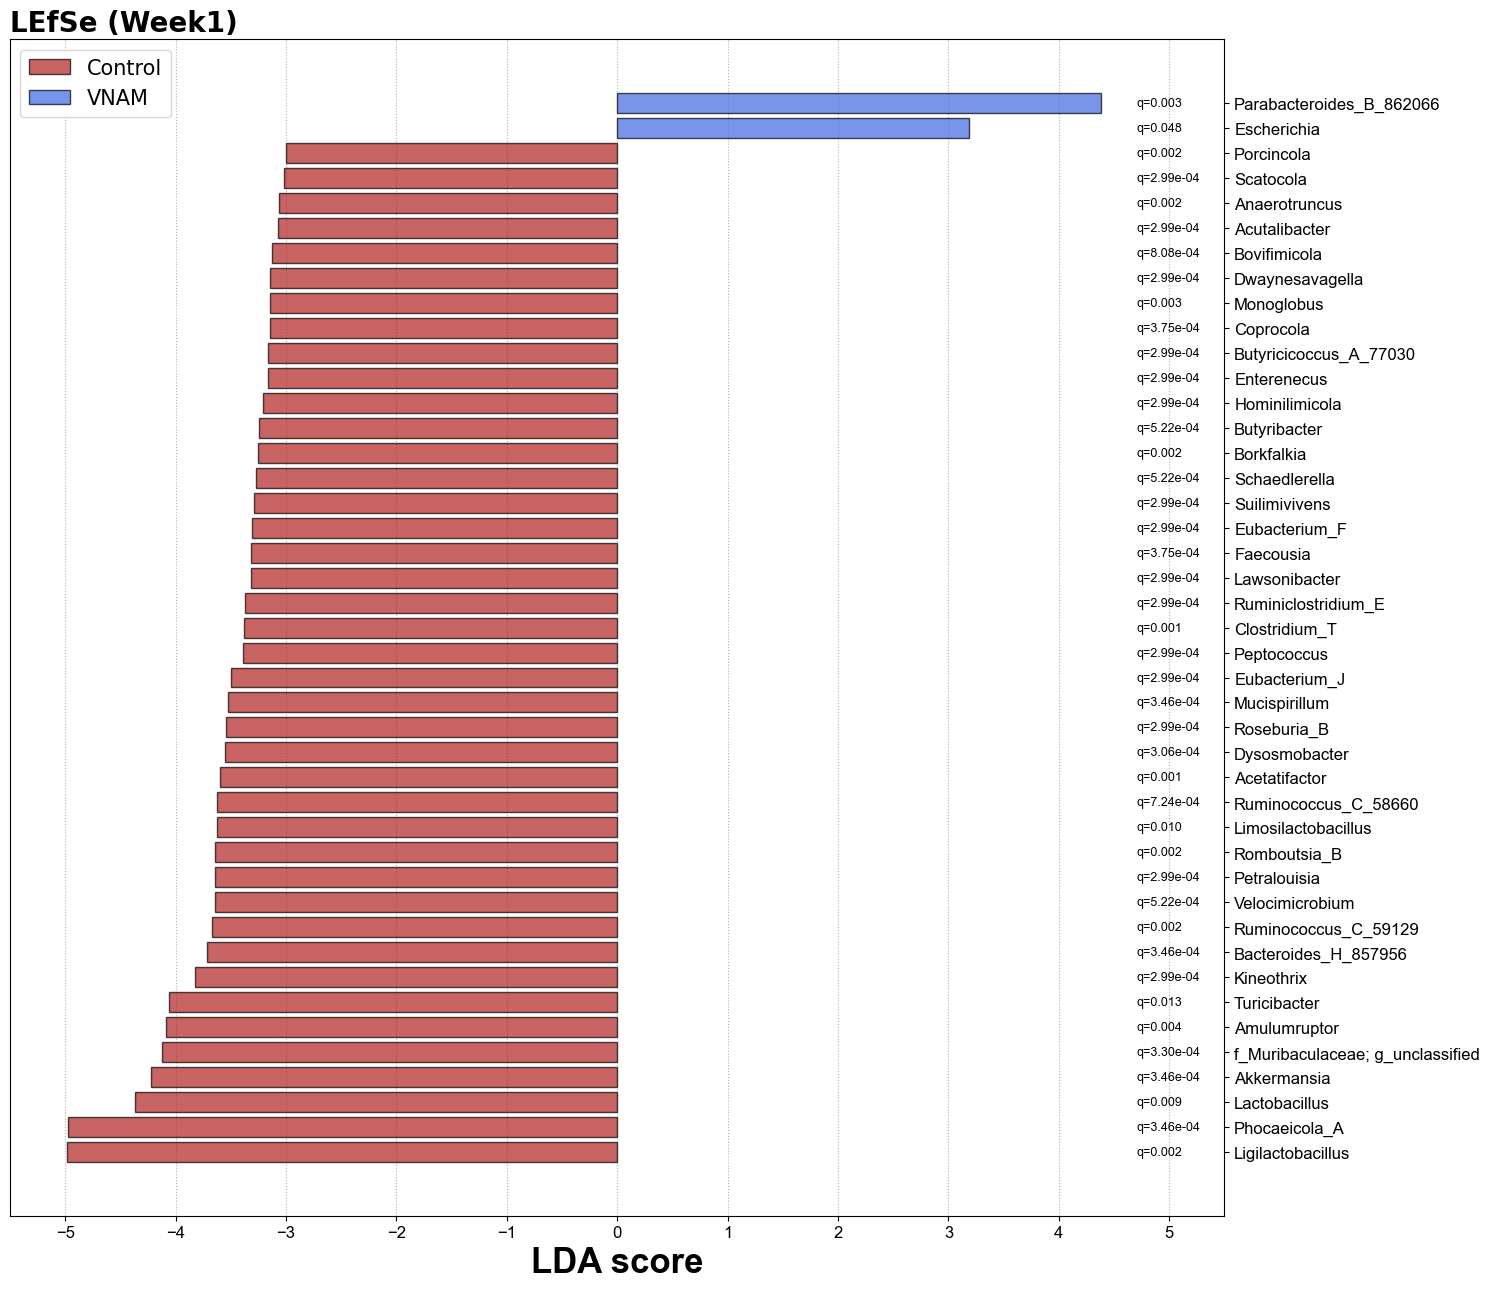

In [85]:
plt.figure(figsize=(15, 13))  #Edit

# Effect Size를 float로 변환
float_Before = Before['LD2'].astype(float).tolist()
float_After = After['LD2'].astype(float).tolist()

# x축 범위 설정
Mini = math.floor(min(float_Before))
Maxi = math.ceil(max(float_After))

x_range = list(range(Mini-10, Maxi+10, 1))  # xticks 간격 조절
plt.xticks(x_range, fontsize=12, fontname='Arial')

# 양수와 음수 데이터 분리
negative_effects = df_ld3_masked[df_ld3_masked['LD2'] < 0]  #Edit: masking 안된 데이터 쓰려면 이 부분 변경
positive_effects = df_ld3_masked[df_ld3_masked['LD2'] > 0]  #Edit: masking 안된 데이터 쓰려면 이 부분 변경

y_pos_negative = np.arange(len(Before))
y_pos_positive = len(Before) + np.arange(len(After))

bars_negative = plt.barh(y_pos_negative, Before['LD2'], color='firebrick', alpha=0.7, edgecolor='k', label='Control', zorder=3)  #Edit
bars_positive = plt.barh(y_pos_positive, After['LD2'], color='royalblue', alpha=0.7, edgecolor='k', label='VNAM', zorder=3)  #Edit
## LDA plot default color: negative-'r' / positive-'g'



# 눈금선을 점선으로 설정, 막대 그래프 뒤로 보내기
plt.grid(True, axis='x', linestyle='dotted', zorder=0)
        
# y축에 카테고리 이름 표시
plt.yticks(np.concatenate([y_pos_negative, y_pos_positive]), 
           np.concatenate([negative_effects['Genus'], positive_effects['Genus']]),  #Edit: 비교 원하는 Taxa Level 입력
           fontsize=12,
           fontname='Arial')


# q-value를 조건부로 표시
df_ld3_masked['q-val'] = pd.to_numeric(df_ld3_masked['q-val'], errors='coerce')
for i, q_val in enumerate(df_ld3_masked['q-val']):
    if q_val < 0.001:
        q_val_str = f'{q_val:.2e}'  # 지수 표기법
    else:
        q_val_str = f'{q_val:.3f}'  # 일반 표기법

    plt.text(
        4.7,  #Edit: x축 위치를 그래프의 오른쪽 바깥쪽으로 설정 (5로 이동)
        i, 
        f'q={q_val_str}',  # 조건부로 p-value 표시
        va='center', ha='left', color='k', fontsize=9, fontname='Arial',
        transform=plt.gca().transData
    )    

plt.xlim(-5.5, 5.5)
plt.xlabel('LDA score', fontsize=25, fontname='Arial', fontweight='bold')
plt.ylabel('')
ax = plt.gca()
ax.yaxis.set_ticks_position('right')
plt.title('LEfSe (Week1)', fontsize=20, loc='left', fontweight='bold')
#plt.legend(bbox_to_anchor=(1.01, 1.01), fontsize=8.5, edgecolor='grey')

plt.tight_layout()

plt.legend(fontsize=15, loc='best')  #Edit

#plt.savefig("lda.pdf", dpi=500, format='pdf', bbox_inches='tight')
plt.savefig("lda_fdr_BKY.png", dpi=500, bbox_inches='tight')

plt.show()